In [1]:
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 23.4 MB/s eta 0:00:00


In [12]:
import random
import math
from collections import deque, namedtuple
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

In [3]:
@dataclass
class Args:
    """DQN hyperparameters."""
    env_name: str = "LunarLander-v3"
    seed: int = 42

    # Training hyperparameters
    gamma: float = 0.99
    lr: float = 1e-3
    batch_size: int = 64
    buffer_size: int = 100_000
    min_replay_size: int = 5_000

    # Exploration parameters
    eps_start: float = 1.0
    eps_end: float = 0.05
    eps_decay: int = 50_000  # steps

    # Training frequency parameters
    target_update_freq: int = 1_000  # steps
    max_episodes: int = 1000
    max_steps_per_episode: int = 1000

    # Network architecture
    hidden_dim: int = 128
    train_freq: int = 1


args = Args()

In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [5]:
class QNetwork(nn.Module):
    """Q-function approximator using a feedforward neural network."""

    def __init__(self, observation_shape: int, action_shape: int, hidden_dim: int = 512):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(observation_shape, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, action_shape)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass through the network."""
        return self.network(x)

In [6]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])


class ReplayBuffer:
    """Experience replay buffer for off-policy learning."""

    def __init__(self, capacity: int) -> None:
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done) -> None:
        """Add a transition to the buffer."""
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        """Sample a random batch of transitions."""
        batch = random.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self) -> int:
        return len(self.buffer)

In [7]:
class DQNAgent:
    """DQN agent with experience replay and target network."""

    def __init__(self, state_dim: int, action_dim: int):
        self.action_dim = action_dim
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        torch.set_default_device(device)

        # Initialize networks
        self.online_net = QNetwork(state_dim, action_dim, args.hidden_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim, args.hidden_dim).to(device)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        # Optimizer
        self.optimizer = optim.Adam(self.online_net.parameters(), lr=args.lr)

        # Training state
        self.steps_done = 0

        # Replay buffer
        self.replay_buffer = ReplayBuffer(args.buffer_size)

    def epsilon(self) -> float:
        """Compute current epsilon for epsilon-greedy exploration."""
        return args.eps_end + (args.eps_start - args.eps_end) * math.exp(-1.0 * self.steps_done / args.eps_decay)

    def select_action(self, state, greedy: bool = False) -> int:
        """Select an action using epsilon-greedy policy.

        Args:
            state: Current observation
            greedy: If True, select greedy action (used during evaluation)

        Returns:
            Selected action index
        """
        eps = 0.0 if greedy else self.epsilon()
        self.steps_done += 0 if greedy else 1

        if random.random() < eps:
            return random.randrange(self.action_dim)

        device = next(self.online_net.parameters()).device
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.online_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def train_step(self) -> float | None:
        """Perform a single training step.

        Returns:
            Loss value if enough samples are available, None otherwise
        """
        if len(self.replay_buffer) < args.min_replay_size:
            return None

        device = next(self.online_net.parameters()).device
        states, actions, rewards, next_states, dones = self.replay_buffer.sample(args.batch_size)

        states_t = torch.tensor(states, dtype=torch.float32, device=device)
        actions_t = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)
        rewards_t = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        next_states_t = torch.tensor(next_states, dtype=torch.float32, device=device)
        dones_t = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

        # Current Q(s, a)
        current_q = self.online_net(states_t).gather(1, actions_t)

        # Target: r + gamma * max_a' Q_target(s', a')
        with torch.no_grad():
            max_next_q = self.target_net(next_states_t).max(dim=1, keepdim=True)[0]
            target_q = rewards_t + args.gamma * (1.0 - dones_t) * max_next_q

        loss = nn.MSELoss()(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.online_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        return loss.item()

    def update_target(self) -> None:
        """Synchronize target network with online network."""
        self.target_net.load_state_dict(self.online_net.state_dict())

    def save(self, path: str = "dqn_lunarlander.pt") -> None:
        """Save the online network state dict."""
        torch.save(self.online_net.state_dict(), path)

    def load(self, path: str = "dqn_lunarlander.pt") -> None:
        """Load network weights from file."""
        device = next(self.online_net.parameters()).device
        self.online_net.load_state_dict(torch.load(path, map_location=device))
        self.target_net.load_state_dict(self.online_net.state_dict())


In [8]:
def evaluate(agent: DQNAgent, env: gym.Env, episodes: int = 5, render: bool = False) -> float:
    """Evaluate agent performance over multiple episodes.

    Args:
        agent: The DQN agent to evaluate
        env: Environment instance
        episodes: Number of episodes to run
        render: Whether to use human rendering mode

    Returns:
        Average total reward across episodes
    """
    rewards = []

    for ep in range(episodes):
        if render:
            env.close()
            env = gym.make(args.env_name, render_mode="human")

        state, _ = env.reset(seed=args.seed + ep)
        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            action = agent.select_action(state, greedy=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return float(np.mean(rewards))

In [13]:
def train() -> list[float]:
    """Train the DQN agent on LunarLander-v3.

    Returns:
        List of episode rewards over training
    """
    set_seed(args.seed)

    env = gym.make(args.env_name)
    eval_env = gym.make(args.env_name)

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = DQNAgent(state_dim, action_dim)

    # Initial random fill of replay buffer
    state, _ = env.reset(seed=args.seed)
    for _ in range(args.min_replay_size):
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        agent.replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        if done or truncated:
            state, _ = env.reset()

    episode_rewards = []
    best_eval_reward = -float("inf")
    global_step = 0

    for episode in tqdm(range(1, args.max_episodes + 1)):
        state, _ = env.reset()
        episode_reward = 0.0
        losses = []

        for _ in range(args.max_steps_per_episode):
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(state, action, reward, next_state, done)
            state = next_state
            episode_reward += reward
            global_step += 1

            if global_step % args.train_freq == 0:
                loss = agent.train_step()
                if loss is not None:
                    losses.append(loss)

            if global_step % args.target_update_freq == 0:
                agent.update_target()

            if done:
                break

        episode_rewards.append(episode_reward)
        avg_reward = np.mean(episode_rewards[-100:])
        avg_loss = np.mean(losses) if losses else 0.0

        # Periodic evaluation
        if episode % 20 == 0:
            eval_reward = evaluate(agent, eval_env, episodes=5)
            print(
                f"Episode {episode:4d} | "
                f"Reward: {episode_reward:8.2f} | "
                f"Epsilon: {agent.epsilon():.3f} | "
                f"Loss: {avg_loss:.4f}"
            )

            if eval_reward > best_eval_reward:
                best_eval_reward = eval_reward
                agent.save("best_dqn_lunarlander.pt")
                print("  Saved new best model.")

    env.close()
    eval_env.close()
    return episode_rewards

In [14]:
rewards = train()

  0%|          | 0/1000 [00:00<?, ?it/s]

Episode   20 | Reward:  -263.64 | Epsilon: 0.963 | Loss: 71.1932
  Saved new best model.
Episode   40 | Reward:  -141.72 | Epsilon: 0.930 | Loss: 51.5758
  Saved new best model.
Episode   60 | Reward:  -212.17 | Epsilon: 0.899 | Loss: 56.5771
  Saved new best model.
Episode   80 | Reward:   -75.82 | Epsilon: 0.868 | Loss: 59.1510
  Saved new best model.
Episode  100 | Reward:   -54.89 | Epsilon: 0.833 | Loss: 52.2433
Episode  120 | Reward:   -69.84 | Epsilon: 0.796 | Loss: 36.1542
Episode  140 | Reward:   -53.13 | Epsilon: 0.763 | Loss: 50.4045
Episode  160 | Reward:   -79.18 | Epsilon: 0.731 | Loss: 46.2506
  Saved new best model.
Episode  180 | Reward:   -25.40 | Epsilon: 0.699 | Loss: 39.8110
Episode  200 | Reward:   -35.11 | Epsilon: 0.669 | Loss: 55.7179
Episode  220 | Reward:   -38.66 | Epsilon: 0.638 | Loss: 54.4182
Episode  240 | Reward:   -62.93 | Epsilon: 0.610 | Loss: 68.1752
Episode  260 | Reward:  -131.85 | Epsilon: 0.583 | Loss: 49.3261
Episode  280 | Reward:   -37.42 | E

In [15]:
def plot_training_results(rewards: list[float]) -> None:
    """Plot training results showing reward per episode.

    Args:
        rewards: List of episode rewards
    """
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))
    plt.plot(rewards, label='Reward per Episode', alpha=0.6, color='tab:blue')

    if len(rewards) >= 10:
        window = min(50, len(rewards))
        means = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(np.arange(window-1, len(rewards)), means, color='blue', lw=2, label=f'Rolling Mean ({window})')

    plt.title('DQN Training Performance: LunarLander-v3')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

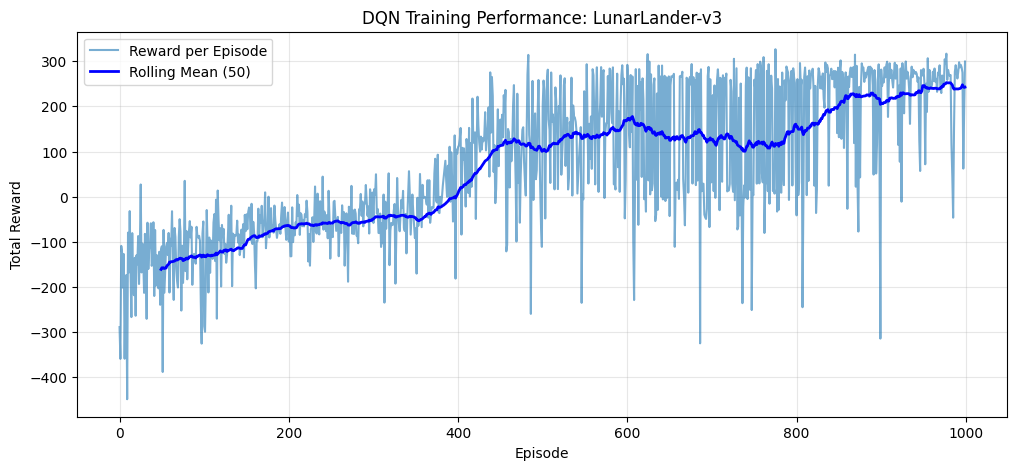

In [16]:
plot_training_results(rewards)

In [17]:
from IPython.display import Image, display

def record_gif(checkpoint_path: str, filename: str = 'simulation.gif') -> str:
    """Load a trained model and generate a simulation GIF.

    Args:
        checkpoint_path: Path to saved model weights
        filename: Output GIF filename

    Returns:
        Path to the generated GIF file
    """
    import imageio

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Reconstruct environment to get dimensions
    temp_env = gym.make(args.env_name)
    obs_dim = temp_env.observation_space.shape[0]
    action_dim = temp_env.action_space.n
    temp_env.close()

    # Initialize agent and load weights
    agent = DQNAgent(obs_dim, action_dim)
    agent.load(checkpoint_path)
    agent.online_net.eval()

    env = gym.make(args.env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=42)
    frames = []
    done = False
    truncated = False
    total_reward = 0

    print(f"Simulating using {checkpoint_path}...")
    while not (done or truncated):
        frames.append(env.render())
        with torch.no_grad():
            obs_t = torch.as_tensor(obs, dtype=torch.float32).to(device).unsqueeze(0)
            q_values = agent.online_net(obs_t)
            action = torch.argmax(q_values, dim=1).item()
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        done = terminated
        truncated = truncated

    env.close()
    print(f"Total Reward: {total_reward:.2f}")
    imageio.mimsave(filename, frames, fps=30)
    return filename

Simulating using /content/best_dqn_lunarlander.pt...
Total Reward: 270.74


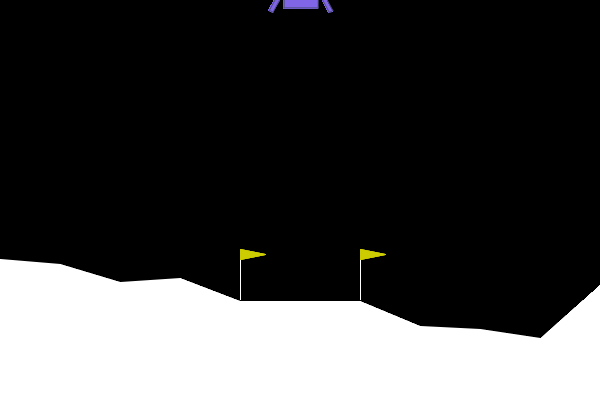

In [18]:
gif_path = record_gif('/content/best_dqn_lunarlander.pt')
display(Image(filename=gif_path))